# **Future Of Deep Learning**

**Laboratorium:** Techniki sieci Feed-Forward w PyTorch

**Zadanie**: Zbuduj klasyfikator zdolności kredytowej z użyciem zbioru Bank Marketing Dataset

**Dane:** Zbiór  służy do analizy i predykcji decyzji kredytowych (czy klient otrzyma loan: yes/no). Zawiera dane marketingowe uzyskane z banków, np. cechy klientów, wcześniejsze interakcje i informacje demograficzne, które mogą wpływać na decyzję o przyznaniu pożyczki

**Źródło:** https://www.kaggle.com/datasets/janiobachmann/bank-marketing-dataset

## Definicje

###Early stopping

Early stopping zatrzymuje proces uczenia w momencie, gdy model przestaje poprawiać wyniki na zbiorze walidacyjnym. W typowym przebiegu po kilku epokach strata treningowa nadal maleje, ale walidacyjna zaczyna rosnąć — to sygnał, że model zaczyna zapamiętywać dane zamiast się z nich uczyć. Zatrzymanie treningu w tym punkcie pozwala uzyskać najlepszy kompromis między dokładnością a zdolnością generalizacji.

W PyTorch Early Stopping implementuje się ręcznie w pętli treningowej: po każdej epoce sprawdzamy wartość straty walidacyjnej i jeśli nie poprawia się przez określoną liczbę epok (patience), przerywamy trening. Można też zapisać wagi modelu z najlepszą stratą, aby przywrócić je po zatrzymaniu. Najlepiej zaimplementować w tym celu dedykowaną klasę.

### Batch size

Batch size to liczba próbek danych przetwarzanych jednocześnie w jednej iteracji treningu sieci.

Mały batch size powoduje, że gradienty są obliczane na niewielkiej liczbie przykładów, co wprowadza szum i może pomagać w unikaniu lokalnych minimów, ale uczenie staje się wolniejsze i mniej stabilne. Duży batch size generuje dokładniejsze gradienty, co przyspiesza i stabilizuje uczenie, ale wymaga więcej pamięci i może prowadzić do gorszej generalizacji. Wybór batch size to kompromis między szybkością uczenia, stabilnością i zdolnością modelu do generalizacji na nowych danych.

Batch size w PyTorch ustawia się przy inicjowaniu DataLoader poprzez przekazanie parametru do kontruktora.


### Optymalizator

 Optymalizator to algorytm, który aktualizuje wagi sieci neuronowej w trakcie uczenia, minimalizując funkcję straty / kosztu. Działa poprzez obliczanie gradientów, czyli pochodnych funkcji straty względem poszczególnych wag, które wskazują kierunek najszybszego wzrostu błędu, a następnie stosowanie ich do aktualizacji wag w przeciwnym kierunku, aby zmniejszyć stratę. W ten sposób model stopniowo dopasowuje swoje parametry, poprawiając dokładność predykcji i generalizację.

 Optymalizator w PyTorch inicjalizuje się na podstawie parametrów modelu.

Różnice podstawowych optymalizatorów:

* SGD (Stochastic Gradient Descent): prosty, używa średniego gradientu z batcha; wymaga dobrego doboru learning rate; może „skakać” w kierunku minimum.
* Adam: łączy momentum i skalowanie gradientu przez ich średnie kwadratów; szybkie i stabilne uczenie; klasyczny Adam stosuje weight_decay w nieoptymalny sposób.
* AdamW: poprawiona wersja Adama, weight_decay jest oddzielone od gradientu; stabilniejsza regularyzacja L2.
* RMSProp: skaluje learning rate przez średnią kwadratów ostatnich gradientów; dobrze działa w problemach z niestacjonarnymi gradientami, np. w RNN

### Principal Component Analysis (PCA)

PCA używane jest jako narzędzie redukcji wymiarów danych. Polega na przekształceniu pierwotnego zestawu cech w nowy zestaw, zwany głównymi składowymi, który zachowuje jak najwięcej wariancji danych (najwięcej informacji o różnicach między obserwacjami) przy mniejszej liczbie wymiarów.

Celem PCA jest uproszczenie danych, zmniejszenie szumu i korelacji między cechami. Dzięki temu model uczy się na informacyjnych kombinacjach cech zamiast na wszystkich oryginalnych zmiennych. Redukcja wymiarów poprawia też wizualizację danych i może zwiększyć stabilność oraz generalizację modelu.

PCA nie jest wbudowane w PyTorch, stosuje się je najczęściej poprzez wywołanie metody z scikit-learn, a wynik przekazuje się później do tensora PyTorch.

## Kontynuacja zadania z poprzednich laboratoriów...

In [15]:
import pandas as pd
import numpy as np
import os

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import f1_score, recall_score, accuracy_score
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

import kagglehub
import os
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

import copy
import time

# Pobranie zestawu danych z Kaggle przez kagglehub
path = kagglehub.dataset_download("janiobachmann/bank-marketing-dataset")

# Lista wszystkich plików CSV w pobranym katalogu
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]

# Pełna ścieżka do pierwszego pliku CSV
csv_path = os.path.join(path, csv_files[0])

# Wczytanie danych do DataFrame
df = pd.read_csv(csv_path, sep=',')

# Rozdzielenie cech (X) od etykiety docelowej (y)
X = df.drop('loan', axis=1) #nasze zmienne objaśniające / predyktory
# Mapowanie wartości 'yes' -> 1 i 'no' -> 0 dla kolumny docelowej
y = df['loan'].map({'yes': 1, 'no': 0}) #nasza zmienna zależna / target

# Wybór kolumn kategorycznych i numerycznych
categorical_cols = X.select_dtypes(include=['object', 'category']).columns
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns

# Mapowanie nazw miesięcy na liczby
month_map = {
    'jan': 1, 'feb': 2, 'mar': 3, 'apr': 4,
    'may': 5, 'jun': 6, 'jul': 7, 'aug': 8,
    'sep': 9, 'oct': 10, 'nov': 11, 'dec': 12
}

# Mapowanie poziomu wykształcenia na liczby
education_map = {
    'primary': 1, 'secondary': 2, 'tertiary': 3, 'unknown': 0
}

# Tworzymy kopię danych kategorycznych
X_cat_encoded = X[categorical_cols].copy()

# Kodowanie kolumn kategorycznych
for col in categorical_cols:
    if col == 'month':
        # Mapowanie miesięcy na liczby
        X_cat_encoded[col] = X_cat_encoded[col].map(month_map)
    elif col == 'education':
        # Mapowanie wykształcenia na liczby
        X_cat_encoded[col] = X_cat_encoded[col].map(education_map)
    else:
        # Dla pozostałych kolumn kategorycznych użycie LabelEncoder (każda unikalna wartość kategorii dostaje unikalną liczbę całkowitą.)
        le = LabelEncoder()
        X_cat_encoded[col] = le.fit_transform(X_cat_encoded[col].astype(str))

# Standaryzacja kolumn numerycznych - standaryzujemy, żeby wszystkie cechy numeryczne miały podobną skalę (średnia = 0, odchylenie standardowe = 1).
# To zapobiega dominacji cech o dużych wartościach i przyspiesza oraz stabilizuje uczenie
scaler = StandardScaler()
X_num_scaled = pd.DataFrame(
    scaler.fit_transform(X[numeric_cols]),  # skalowanie wartości
    columns=numeric_cols,                   # zachowanie nazw kolumn
    index=X.index                            # zachowanie indeksów
)

# Łączenie kolumn numerycznych i zakodowanych kategorycznych
X_prepared = pd.concat([X_num_scaled, X_cat_encoded], axis=1)

# Podział danych na zbiór treningowy i testowy (70%/30%) z zachowaniem proporcji klas
X_train, X_test, y_train, y_test = train_test_split(
    X_prepared, y, test_size=0.3, random_state=42, stratify=y
)

# Wyświetlenie rozmiarów zbiorów
print("Rozmiar zbioru treningowego:", X_train.shape)
print("Rozmiar zbioru testowego:", X_test.shape)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# 1 - przygotowane dane zmieniamy na Tensory, bo będziemy używać Pytorcha
X_train_tensor = torch.FloatTensor(X_train.values)
X_test_tensor = torch.FloatTensor(X_test.values)
y_train_tensor = torch.LongTensor(y_train.values)
y_test_tensor = torch.LongTensor(y_test.values)

# 2 - TensorDataset łączy cechy X i etykiety y w spójny zbiór danych, gdzie każda etykieta jest dopasowana do swoich cech
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# 3 - DataLoader dzieli dane na batch’e, co przyspiesza trening i stabilizuje uczenie.
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
# shuffle=True/False - na treningu mieszamy dane, test nie! tam kolejność nie ma dla nas znaczenia
# w treningu model moze się nauczyć nie wzorców a koeljności

Using Colab cache for faster access to the 'bank-marketing-dataset' dataset.
Rozmiar zbioru treningowego: (7813, 16)
Rozmiar zbioru testowego: (3349, 16)
Device: cpu


In [16]:
def train_and_evaluate(model,
                       train_loader,
                       test_loader,
                       num_epochs=30,
                       learning_rate=0.01,
                       weight_decay=0.0,
                       device='cpu',
                       verbose=True,
                       plot=True):
    """
    Trenuje model, zwraca wyniki i rysuje wykresy strat oraz dokładności.

    Args:
        model: instancja nn.Module
        train_loader: DataLoader dla zbioru treningowego
        test_loader: DataLoader dla zbioru testowego (walidacyjnego)
        num_epochs: liczba epok
        learning_rate: współczynnik uczenia
        weight_decay: L2 regularization
        device: 'cpu' lub 'cuda'
        verbose: czy wypisywać postęp
        plot: czy wyświetlić wykresy

    Returns:
        dict z wynikami: train_losses, val_losses, train_accs, val_accs, model
    """

    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

    train_losses, train_accs = [], []
    val_losses, val_accs = [], []

    for epoch in range(num_epochs):
        # Trening
        model.train()
        total_loss = 0
        correct_train, total_train = 0, 0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            outputs = model(xb)
            loss = criterion(outputs, yb)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * xb.size(0)
            preds = torch.argmax(outputs, dim=1)
            correct_train += (preds == yb).sum().item()
            total_train += yb.size(0)

        train_loss = total_loss / total_train
        train_acc = correct_train / total_train

        # Walidacja
        model.eval()
        val_loss_total = 0
        correct_val, total_val = 0, 0

        with torch.no_grad():
            for xb, yb in test_loader:
                xb, yb = xb.to(device), yb.to(device)
                outputs = model(xb)
                loss = criterion(outputs, yb)
                val_loss_total += loss.item() * xb.size(0)

                preds = torch.argmax(outputs, dim=1)
                correct_val += (preds == yb).sum().item()
                total_val += yb.size(0)

        val_loss = val_loss_total / total_val
        val_acc = correct_val / total_val

        train_losses.append(train_loss)
        train_accs.append(train_acc)
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        if verbose:
            print(f"Epoch {epoch+1}/{num_epochs} | "
                  f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
                  f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    # Wykresy
    if plot:
        epochs_range = range(1, num_epochs + 1)
        plt.figure(figsize=(12, 5))

        # Wykres strat
        plt.subplot(1, 2, 1)
        plt.plot(epochs_range, train_losses, label='Train Loss')
        plt.plot(epochs_range, val_losses, label='Validation Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Loss over Epochs')
        plt.legend()
        plt.grid(True)

        # Wykres dokładności
        plt.subplot(1, 2, 2)
        plt.plot(epochs_range, train_accs, label='Train Accuracy')
        plt.plot(epochs_range, val_accs, label='Validation Accuracy')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.title('Accuracy over Epochs')
        plt.legend()
        plt.grid(True)

        plt.tight_layout()
        plt.show()

    return {
        'model': model,
        'train_losses': train_losses,
        'train_accs': train_accs,
        'val_losses': val_losses,
        'val_accs': val_accs
    }

In [17]:
class DeepFFNN(nn.Module):
    def __init__(self, input_size, hidden1_size, hidden2_size, output_size):
        super(DeepFFNN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden1_size)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(hidden1_size, hidden2_size) # dodatkowa warstwa
        self.relu2 = nn.ReLU()                           # dodatkowa funkcja aktywacji
        self.fc3 = nn.Linear(hidden2_size, output_size)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        return x

input_size = X_train.shape[1]
hidden1_size = 32
hidden2_size = 16
output_size = len(np.unique(y_train))

model_deepffnn = DeepFFNN(input_size, hidden1_size, hidden2_size, output_size).to(device)

### 8. Eksperymenty z Early Stopping i Batch Size
* Zaimplementuj EarlyStopping (np. patience=5, restore_best_weights=True).
* Porównaj trening dla różnych rozmiarów batcha: 16, 32, 128.
* Zbadaj wpływ tych parametrów na szybkość uczenia i wynik walidacyjny.
* **Odpowiedz**: czy mniejszy batch poprawił generalizację modelu?

In [18]:
def earlystopping_train_and_evaluate(model,
                          train_loader,
                          test_loader,
                          num_epochs=30,
                          learning_rate=0.01,
                          weight_decay=0.0,
                          device='cpu',
                          verbose=True,
                          plot=True,
                          patience=5,
                          restore_best_weights=True):

    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

    train_losses, train_accs = [], []
    val_losses, val_accs = [], []

    best_val_loss = float('inf')
    epochs_no_improve, best_epoch = 0, 0
    best_model_weights = copy.deepcopy(model.state_dict())

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        correct_train, total_train = 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            outputs = model(xb)
            loss = criterion(outputs, yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * xb.size(0)
            preds = torch.argmax(outputs, dim=1)
            correct_train += (preds == yb).sum().item()
            total_train += yb.size(0)
        train_loss = total_loss / total_train
        train_acc = correct_train / total_train

        model.eval()
        val_loss_total = 0
        correct_val, total_val = 0, 0
        with torch.no_grad():
            for xb, yb in test_loader:
                xb, yb = xb.to(device), yb.to(device)
                outputs = model(xb)
                loss = criterion(outputs, yb)
                val_loss_total += loss.item() * xb.size(0)
                preds = torch.argmax(outputs, dim=1)
                correct_val += (preds == yb).sum().item()
                total_val += yb.size(0)
        val_loss = val_loss_total / total_val
        val_acc = correct_val / total_val

        train_losses.append(train_loss)
        train_accs.append(train_acc)
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        if verbose:
            print(f"Epoch {epoch+1}/{num_epochs} | "
                  f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
                  f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}", end="")

        # EARLY STOPPING CHECK
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            best_model_weights = copy.deepcopy(model.state_dict())
            best_epoch = epoch + 1
            if verbose:
                print(f"\t > Best res (Val Loss: {best_val_loss:.4f})")
        else:
            epochs_no_improve += 1
            if verbose:
                print(f"\t > No posititve results {epochs_no_improve} epochs")

        if epochs_no_improve >= patience:
            print(f"\nEARLY STOPPING! After {epoch + 1} epochs.")
            break

    # Wykresy
    if plot:
        epochs_range = range(1, len(train_losses) + 1) # uwzględnienie faktu early stoping
        plt.figure(figsize=(12, 5))

        plt.subplot(1, 2, 1)
        plt.plot(epochs_range, train_losses, label='Train Loss')
        plt.plot(epochs_range, val_losses, label='Validation Loss')
        # best epoch marker
        plt.axvline(best_epoch, color='r', linestyle='--', label=f'Best Epoch ({best_epoch})')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Loss over Epochs')
        plt.legend()
        plt.grid(True)

        plt.subplot(1, 2, 2)
        plt.plot(epochs_range, train_accs, label='Train Accuracy')
        plt.plot(epochs_range, val_accs, label='Validation Accuracy')
        plt.axvline(best_epoch, color='r', linestyle='--', label=f'Best Epoch ({best_epoch})')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.title('Accuracy over Epochs')
        plt.legend()
        plt.grid(True)

        plt.tight_layout()
        plt.show()

    if restore_best_weights:
        print(f"Returning weights from best epoch: {best_epoch} (Val Loss: {best_val_loss:.4f})")
        model.load_state_dict(best_model_weights)

    return {
        'model': model,
        'train_losses': train_losses,
        'train_accs': train_accs,
        'val_losses': val_losses,
        'val_accs': val_accs,
        'best_val_loss': best_val_loss,
        'best_val_acc': val_accs[best_epoch-1],
        'stopped_epoch': len(train_losses)
    }


	 Batch Size = 16
Epoch 1/30 | Train Loss: 0.3908, Train Acc: 0.8692 | Val Loss: 0.3714, Val Acc: 0.8692	 > Best res (Val Loss: 0.3714)
Epoch 2/30 | Train Loss: 0.3729, Train Acc: 0.8692 | Val Loss: 0.3695, Val Acc: 0.8692	 > Best res (Val Loss: 0.3695)
Epoch 3/30 | Train Loss: 0.3699, Train Acc: 0.8692 | Val Loss: 0.3708, Val Acc: 0.8692	 > No posititve results 1 epochs
Epoch 4/30 | Train Loss: 0.3683, Train Acc: 0.8692 | Val Loss: 0.3689, Val Acc: 0.8692	 > Best res (Val Loss: 0.3689)
Epoch 5/30 | Train Loss: 0.3678, Train Acc: 0.8692 | Val Loss: 0.3707, Val Acc: 0.8692	 > No posititve results 1 epochs
Epoch 6/30 | Train Loss: 0.3666, Train Acc: 0.8692 | Val Loss: 0.3694, Val Acc: 0.8692	 > No posititve results 2 epochs
Epoch 7/30 | Train Loss: 0.3652, Train Acc: 0.8692 | Val Loss: 0.3687, Val Acc: 0.8692	 > Best res (Val Loss: 0.3687)
Epoch 8/30 | Train Loss: 0.3641, Train Acc: 0.8692 | Val Loss: 0.3695, Val Acc: 0.8692	 > No posititve results 1 epochs
Epoch 9/30 | Train Loss: 0.36

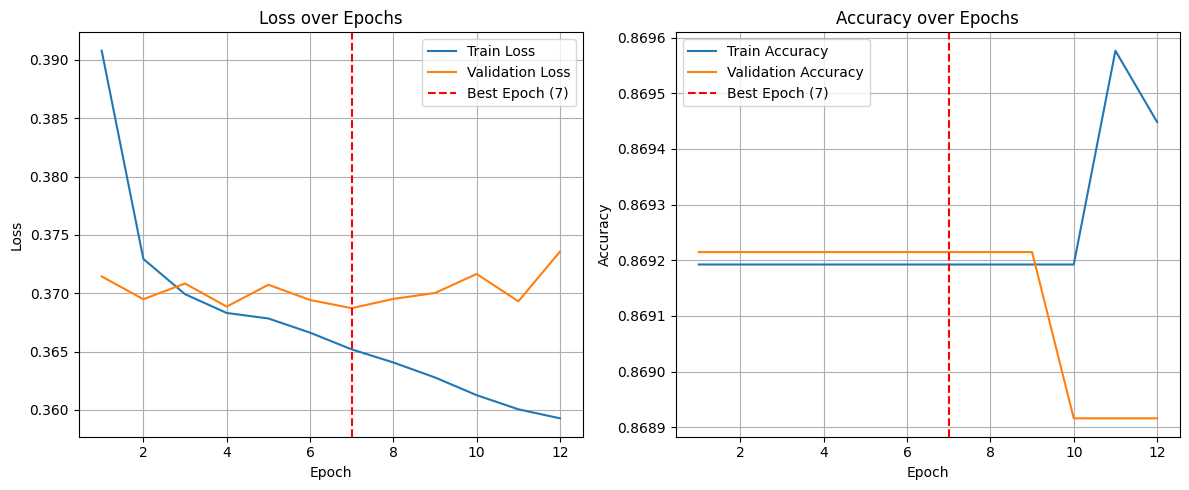

Returning weights from best epoch: 7 (Val Loss: 0.3687)
Wynik dla Batch Size = 16:
	Najlepsza Val Acc: 0.8692
	Osiągnięta w epoce: 12
	Całkowity czas trenowania: 7.43 sekund

	 Batch Size = 32
Epoch 1/30 | Train Loss: 0.4020, Train Acc: 0.8692 | Val Loss: 0.3795, Val Acc: 0.8692	 > Best res (Val Loss: 0.3795)
Epoch 2/30 | Train Loss: 0.3778, Train Acc: 0.8692 | Val Loss: 0.3773, Val Acc: 0.8692	 > Best res (Val Loss: 0.3773)
Epoch 3/30 | Train Loss: 0.3717, Train Acc: 0.8692 | Val Loss: 0.3699, Val Acc: 0.8692	 > Best res (Val Loss: 0.3699)
Epoch 4/30 | Train Loss: 0.3691, Train Acc: 0.8692 | Val Loss: 0.3691, Val Acc: 0.8692	 > Best res (Val Loss: 0.3691)
Epoch 5/30 | Train Loss: 0.3672, Train Acc: 0.8692 | Val Loss: 0.3673, Val Acc: 0.8692	 > Best res (Val Loss: 0.3673)
Epoch 6/30 | Train Loss: 0.3648, Train Acc: 0.8689 | Val Loss: 0.3737, Val Acc: 0.8692	 > No posititve results 1 epochs
Epoch 7/30 | Train Loss: 0.3654, Train Acc: 0.8693 | Val Loss: 0.3680, Val Acc: 0.8692	 > No posi

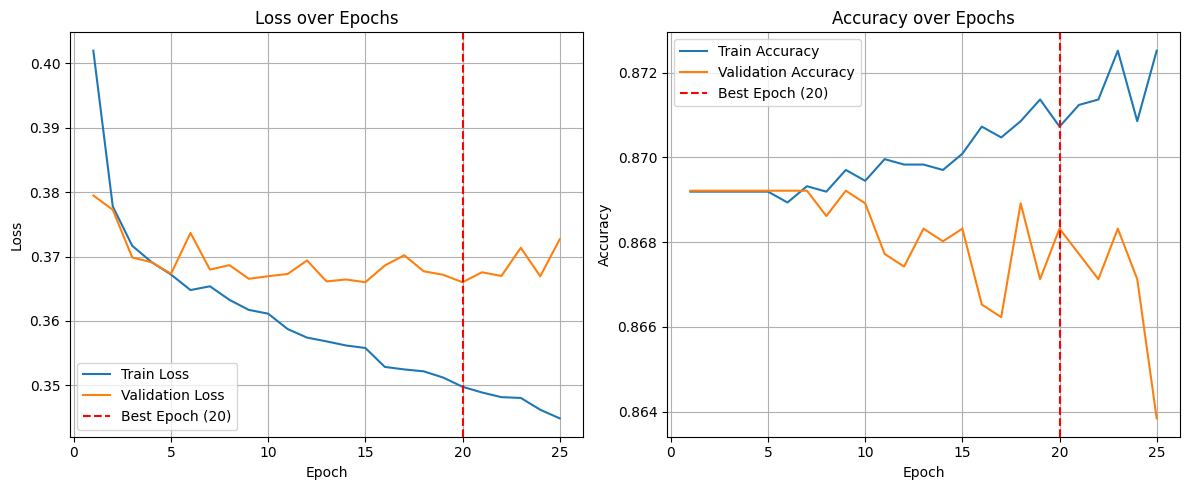

Returning weights from best epoch: 20 (Val Loss: 0.3660)
Wynik dla Batch Size = 32:
	Najlepsza Val Acc: 0.8683
	Osiągnięta w epoce: 25
	Całkowity czas trenowania: 8.64 sekund

	 Batch Size = 128
Epoch 1/30 | Train Loss: 0.4054, Train Acc: 0.8692 | Val Loss: 0.3853, Val Acc: 0.8692	 > Best res (Val Loss: 0.3853)
Epoch 2/30 | Train Loss: 0.3853, Train Acc: 0.8692 | Val Loss: 0.3785, Val Acc: 0.8692	 > Best res (Val Loss: 0.3785)
Epoch 3/30 | Train Loss: 0.3790, Train Acc: 0.8692 | Val Loss: 0.3769, Val Acc: 0.8692	 > Best res (Val Loss: 0.3769)
Epoch 4/30 | Train Loss: 0.3766, Train Acc: 0.8692 | Val Loss: 0.3725, Val Acc: 0.8692	 > Best res (Val Loss: 0.3725)
Epoch 5/30 | Train Loss: 0.3736, Train Acc: 0.8692 | Val Loss: 0.3711, Val Acc: 0.8692	 > Best res (Val Loss: 0.3711)
Epoch 6/30 | Train Loss: 0.3707, Train Acc: 0.8692 | Val Loss: 0.3713, Val Acc: 0.8692	 > No posititve results 1 epochs
Epoch 7/30 | Train Loss: 0.3696, Train Acc: 0.8692 | Val Loss: 0.3705, Val Acc: 0.8692	 > Best 

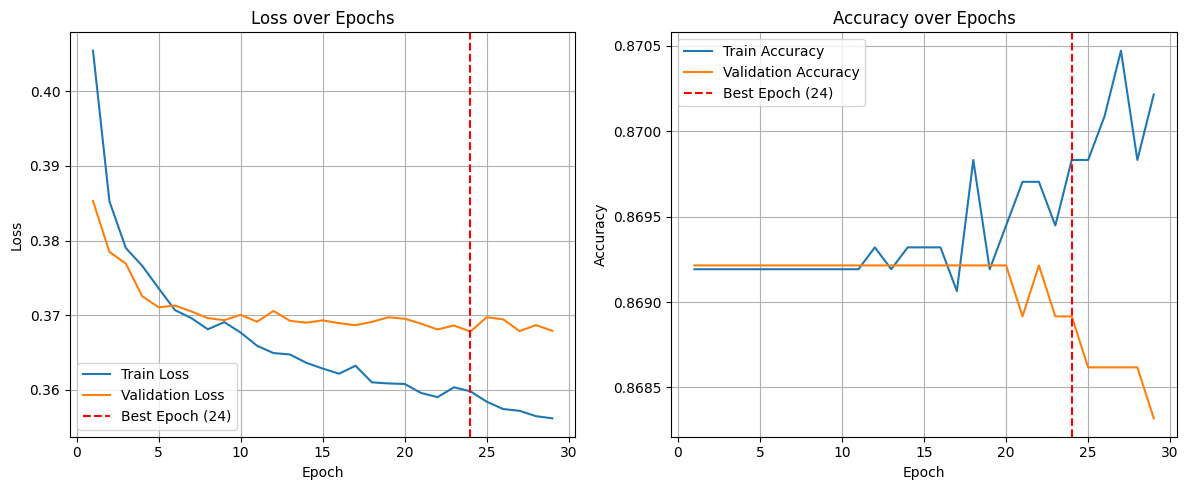

Returning weights from best epoch: 24 (Val Loss: 0.3678)
Wynik dla Batch Size = 128:
	Najlepsza Val Acc: 0.8689
	Osiągnięta w epoce: 29
	Całkowity czas trenowania: 3.84 sekund
Batch Size: 16
	-> Czas: 7.43 s | Najlepsza Val Acc: 0.8692 | Zatrzymano w epoce: 12
Batch Size: 32
	-> Czas: 8.64 s | Najlepsza Val Acc: 0.8683 | Zatrzymano w epoce: 25
Batch Size: 128
	-> Czas: 3.84 s | Najlepsza Val Acc: 0.8689 | Zatrzymano w epoce: 29


In [19]:
batches = [16, 32, 128]
num_epochs = 30
patience = 5
learning_rate = 0.001

batch_results = {}

for batch in batches:
    print(f"\n\t Batch Size = {batch}")

    train_loader = DataLoader(train_dataset, batch_size=batch, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch, shuffle=False)

    model = DeepFFNN(input_size, hidden1_size, hidden2_size, output_size).to(device)

    start_time = time.time()

    results = earlystopping_train_and_evaluate(
        model,
        train_loader,
        test_loader,
        num_epochs=num_epochs,
        learning_rate=learning_rate,
        device=device,
        patience=patience,
        verbose=True,
        plot=True
    )

    end_time = time.time()
    duration = end_time - start_time

    batch_results[batch] = {
        'time_sec': duration,
        'best_val_loss': results['best_val_loss'],
        'best_val_acc': results['best_val_acc'],
        'stopped_epoch': results['stopped_epoch']
    }

    print(f"Wynik dla Batch Size = {batch}:")
    print(f"\tNajlepsza Val Acc: {results['best_val_acc']:.4f}")
    print(f"\tOsiągnięta w epoce: {results['stopped_epoch'] if results['stopped_epoch'] < num_epochs else results['best_epoch_num']}")
    print(f"\tCałkowity czas trenowania: {duration:.2f} sekund")

for bs, metrics in batch_results.items():
    print(f"Batch Size: {bs}")
    print(f"\t-> Czas: {metrics['time_sec']:.2f} s | "
          f"Najlepsza Val Acc: {metrics['best_val_acc']:.4f} | "
          f"Zatrzymano w epoce: {metrics['stopped_epoch']}")

**ODPOWIEDŹ**
- W przypadku naszego datasetu tylko trochę poprawiło wyniki

### 9. Porównanie optymalizatorów
* Wytrenuj ten sam model z optymalizatorami: SGD, Adam, RMSProp.
* Zachowaj ten sam learning rate
* Porównaj konwergencję, stabilność i końcową dokładność.
* **Odpowiedz**: który optymalizator najlepiej sprawdza się dla naszego zbioru danych i przy jakim learning rate?

In [23]:
def optimizer_train_and_evaluate(model,
                                 train_loader,
                                 test_loader,
                                 optimizer_name='Adam',
                                 learning_rate=0.001,
                                 weight_decay=0.0,
                                 num_epochs=50,
                                 patience=5,
                                 restore_best_weights=True,
                                 device='cpu',
                                 verbose=True,
                                 plot=True):

    model = model.to(device)
    criterion = nn.CrossEntropyLoss()

    if optimizer_name == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    elif optimizer_name == 'RMSProp':
        optimizer = optim.RMSprop(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    elif optimizer_name == 'SGD':
        optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9, weight_decay=weight_decay)
    else:
        raise ValueError(f"Error")

    train_losses, train_accs = [], []
    val_losses, val_accs = [], []

    best_val_loss = float('inf')
    epochs_no_improve, best_epoch = 0, 0
    best_model_weights = copy.deepcopy(model.state_dict())

    for epoch in range(num_epochs):
        model.train()
        total_loss, correct_train, total_train = 0, 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            outputs = model(xb)
            loss = criterion(outputs, yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * xb.size(0)
            preds = torch.argmax(outputs, dim=1)
            correct_train += (preds == yb).sum().item()
            total_train += yb.size(0)
        train_loss = total_loss / total_train
        train_acc = correct_train / total_train

        model.eval()
        val_loss_total, correct_val, total_val = 0, 0, 0
        with torch.no_grad():
            for xb, yb in test_loader:
                xb, yb = xb.to(device), yb.to(device)
                outputs = model(xb)
                loss = criterion(outputs, yb)
                val_loss_total += loss.item() * xb.size(0)
                preds = torch.argmax(outputs, dim=1)
                correct_val += (preds == yb).sum().item()
                total_val += yb.size(0)
        val_loss = val_loss_total / total_val
        val_acc = correct_val / total_val

        train_losses.append(train_loss)
        train_accs.append(train_acc)
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        if verbose:
            print(f"Epoch {epoch+1}/{num_epochs} | "
                  f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
                  f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}", end="")

        # EARLY STOPPING CHECK
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            best_model_weights = copy.deepcopy(model.state_dict())
            best_epoch = epoch + 1
            if verbose:
                print(f"\t > Best res (Val Loss: {best_val_loss:.4f})")
        else:
            epochs_no_improve += 1
            if verbose:
                print(f"\t > No posititve results {epochs_no_improve} epochs")

        if epochs_no_improve >= patience:
            print(f"\nEARLY STOPPING! After {epoch + 1} epochs.")
            break

    # Wykresy
    if plot:
        epochs_range = range(1, len(train_losses) + 1)
        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1)
        plt.plot(epochs_range, train_losses, label='Train Loss')
        plt.plot(epochs_range, val_losses, label='Validation Loss')
        plt.axvline(best_epoch, color='r', linestyle='--', label=f'Best Epoch ({best_epoch})')
        plt.title(f'Loss ({optimizer_name}, lr={learning_rate})')
        plt.legend()
        plt.grid(True)
        plt.subplot(1, 2, 2)
        plt.plot(epochs_range, train_accs, label='Train Accuracy')
        plt.plot(epochs_range, val_accs, label='Validation Accuracy')
        plt.axvline(best_epoch, color='r', linestyle='--', label=f'Best Epoch ({best_epoch})')
        plt.title(f'Accuracy ({optimizer_name}, lr={learning_rate})')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    if restore_best_weights:
        print(f"Returning weights from best epoch: {best_epoch} (Val Loss: {best_val_loss:.4f})")
        model.load_state_dict(best_model_weights)

    return {
        'model': model,
        'best_val_loss': best_val_loss,
        'best_val_acc': val_accs[best_epoch-1],
        'stopped_epoch': len(train_losses)
    }


	 Optymalizator = Adam, Learning rate = 0.001
Epoch 1/30 | Train Loss: 0.4234, Train Acc: 0.8492 | Val Loss: 0.3846, Val Acc: 0.8692	 > Best res (Val Loss: 0.3846)
Epoch 2/30 | Train Loss: 0.3781, Train Acc: 0.8692 | Val Loss: 0.3715, Val Acc: 0.8692	 > Best res (Val Loss: 0.3715)
Epoch 3/30 | Train Loss: 0.3701, Train Acc: 0.8692 | Val Loss: 0.3687, Val Acc: 0.8692	 > Best res (Val Loss: 0.3687)
Epoch 4/30 | Train Loss: 0.3673, Train Acc: 0.8692 | Val Loss: 0.3678, Val Acc: 0.8692	 > Best res (Val Loss: 0.3678)
Epoch 5/30 | Train Loss: 0.3657, Train Acc: 0.8693 | Val Loss: 0.3683, Val Acc: 0.8689	 > No posititve results 1 epochs
Epoch 6/30 | Train Loss: 0.3636, Train Acc: 0.8693 | Val Loss: 0.3668, Val Acc: 0.8689	 > Best res (Val Loss: 0.3668)
Epoch 7/30 | Train Loss: 0.3625, Train Acc: 0.8693 | Val Loss: 0.3661, Val Acc: 0.8692	 > Best res (Val Loss: 0.3661)
Epoch 8/30 | Train Loss: 0.3624, Train Acc: 0.8693 | Val Loss: 0.3667, Val Acc: 0.8692	 > No posititve results 1 epochs
Epoch

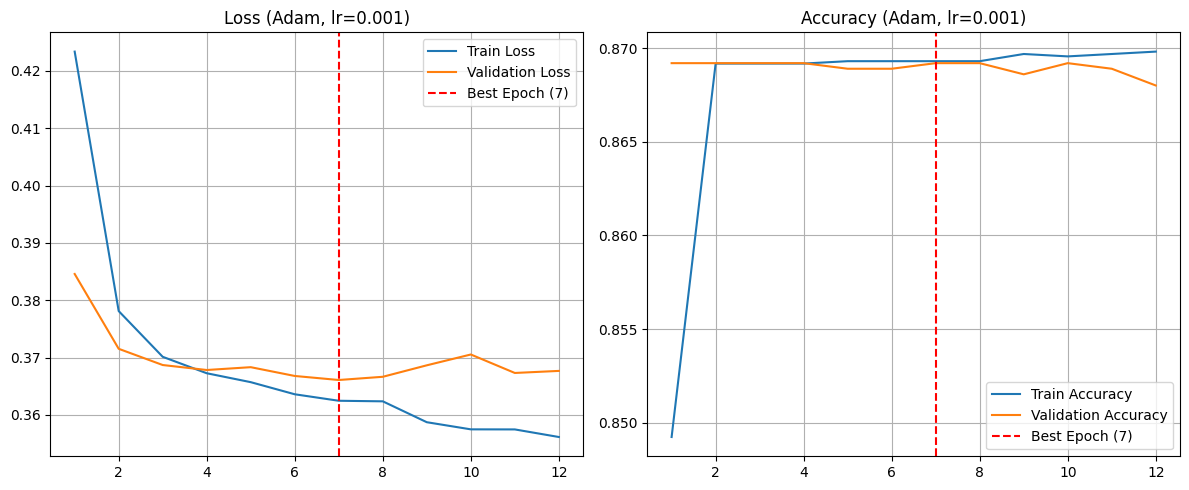

Returning weights from best epoch: 7 (Val Loss: 0.3661)

	 Optymalizator = RMSProp, Learning rate = 0.001
Epoch 1/30 | Train Loss: 0.3924, Train Acc: 0.8598 | Val Loss: 0.3877, Val Acc: 0.8692	 > Best res (Val Loss: 0.3877)
Epoch 2/30 | Train Loss: 0.3751, Train Acc: 0.8692 | Val Loss: 0.3778, Val Acc: 0.8692	 > Best res (Val Loss: 0.3778)
Epoch 3/30 | Train Loss: 0.3723, Train Acc: 0.8692 | Val Loss: 0.3685, Val Acc: 0.8692	 > Best res (Val Loss: 0.3685)
Epoch 4/30 | Train Loss: 0.3700, Train Acc: 0.8692 | Val Loss: 0.3773, Val Acc: 0.8692	 > No posititve results 1 epochs
Epoch 5/30 | Train Loss: 0.3682, Train Acc: 0.8692 | Val Loss: 0.3718, Val Acc: 0.8692	 > No posititve results 2 epochs
Epoch 6/30 | Train Loss: 0.3677, Train Acc: 0.8692 | Val Loss: 0.3721, Val Acc: 0.8689	 > No posititve results 3 epochs
Epoch 7/30 | Train Loss: 0.3673, Train Acc: 0.8693 | Val Loss: 0.3679, Val Acc: 0.8692	 > Best res (Val Loss: 0.3679)
Epoch 8/30 | Train Loss: 0.3669, Train Acc: 0.8693 | Val Loss:

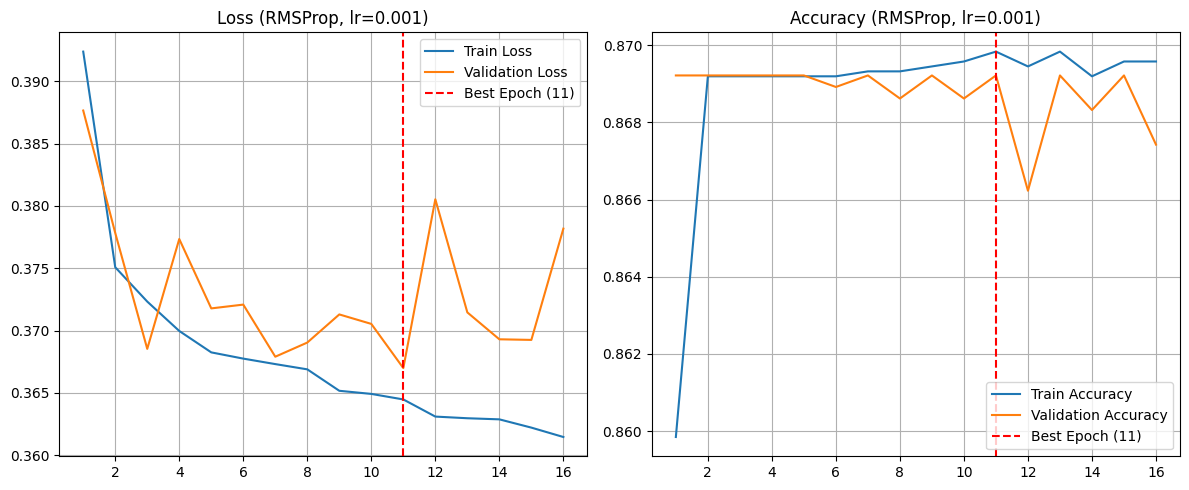

Returning weights from best epoch: 11 (Val Loss: 0.3670)

	 Optymalizator = SGD, Learning rate = 0.001
Epoch 1/30 | Train Loss: 0.4274, Train Acc: 0.8459 | Val Loss: 0.3936, Val Acc: 0.8692	 > Best res (Val Loss: 0.3936)
Epoch 2/30 | Train Loss: 0.3928, Train Acc: 0.8692 | Val Loss: 0.3890, Val Acc: 0.8692	 > Best res (Val Loss: 0.3890)
Epoch 3/30 | Train Loss: 0.3894, Train Acc: 0.8692 | Val Loss: 0.3867, Val Acc: 0.8692	 > Best res (Val Loss: 0.3867)
Epoch 4/30 | Train Loss: 0.3869, Train Acc: 0.8692 | Val Loss: 0.3842, Val Acc: 0.8692	 > Best res (Val Loss: 0.3842)
Epoch 5/30 | Train Loss: 0.3849, Train Acc: 0.8692 | Val Loss: 0.3828, Val Acc: 0.8692	 > Best res (Val Loss: 0.3828)
Epoch 6/30 | Train Loss: 0.3834, Train Acc: 0.8692 | Val Loss: 0.3816, Val Acc: 0.8692	 > Best res (Val Loss: 0.3816)
Epoch 7/30 | Train Loss: 0.3823, Train Acc: 0.8692 | Val Loss: 0.3806, Val Acc: 0.8692	 > Best res (Val Loss: 0.3806)
Epoch 8/30 | Train Loss: 0.3810, Train Acc: 0.8692 | Val Loss: 0.3791, 

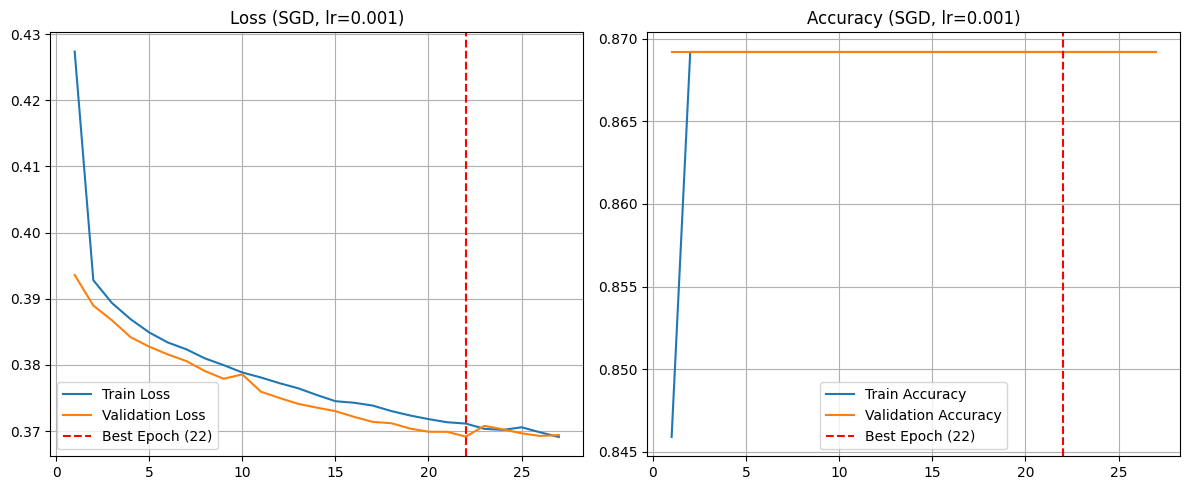

Returning weights from best epoch: 22 (Val Loss: 0.3692)
Optymalizator: Adam
  -> Czas: 4.06 s | Najlepsza Val Acc: 0.8692 | Zatrzymano w epoce: 12
Optymalizator: RMSProp
  -> Czas: 6.52 s | Najlepsza Val Acc: 0.8692 | Zatrzymano w epoce: 16
Optymalizator: SGD
  -> Czas: 9.74 s | Najlepsza Val Acc: 0.8692 | Zatrzymano w epoce: 27


In [27]:
optimizers = ['Adam', 'RMSProp', 'SGD']
learning_rate = 0.001
batch_size = 32
num_epochs = 30
patience = 5
optimizer_results = {}

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

for optimizer in optimizers:
    print(f"\n\t Optymalizator = {optimizer}, Learning rate = {learning_rate}")

    model = DeepFFNN(input_size, hidden1_size, hidden2_size, output_size).to(device)

    start_time = time.time()

    results = optimizer_train_and_evaluate(
        model,
        train_loader,
        test_loader,
        optimizer_name=optimizer,
        learning_rate=learning_rate,
        num_epochs=num_epochs,
        patience=patience,
        device=device,
        verbose=True,
        plot=True
    )

    end_time = time.time()
    duration = end_time - start_time

    optimizer_results[optimizer] = {
        'time_sec': duration,
        'best_val_loss': results['best_val_loss'],
        'best_val_acc': results['best_val_acc'],
        'stopped_epoch': results['stopped_epoch']
    }

for optim_name, metrics in optimizer_results.items():
    print(f"Optymalizator: {optim_name}")
    print(f"  -> Czas: {metrics['time_sec']:.2f} s | "
          f"Najlepsza Val Acc: {metrics['best_val_acc']:.4f} | "
          f"Zatrzymano w epoce: {metrics['stopped_epoch']}")

**ODPOWIEDŹ**
- W przypadku naszego datasetu nie ma dużej różnicy w wynikach optymilizatorów, ale Adam w większości prób pokazywał siebie lepiej (przy learning rate 0.001)

### 10. Regularyzacja

1. Dodaj L2 regularization do warstw.
2. Naucz model i porównaj z wersją bez regularizacji.
3. **Odpowiedz**: czy regularyzacja zmniejszyła overfitting? Uzasadnij swoje obserwacje.


	 L2 weight decay = 0.0 ---
Epoch 1/30 | Train Loss: 0.4081, Train Acc: 0.8642 | Val Loss: 0.3800, Val Acc: 0.8692	 > Best res (Val Loss: 0.3800)
Epoch 2/30 | Train Loss: 0.3782, Train Acc: 0.8692 | Val Loss: 0.3715, Val Acc: 0.8692	 > Best res (Val Loss: 0.3715)
Epoch 3/30 | Train Loss: 0.3727, Train Acc: 0.8692 | Val Loss: 0.3689, Val Acc: 0.8692	 > Best res (Val Loss: 0.3689)
Epoch 4/30 | Train Loss: 0.3690, Train Acc: 0.8692 | Val Loss: 0.3695, Val Acc: 0.8692	 > No posititve results 1 epochs
Epoch 5/30 | Train Loss: 0.3674, Train Acc: 0.8692 | Val Loss: 0.3690, Val Acc: 0.8692	 > No posititve results 2 epochs
Epoch 6/30 | Train Loss: 0.3669, Train Acc: 0.8693 | Val Loss: 0.3707, Val Acc: 0.8692	 > No posititve results 3 epochs
Epoch 7/30 | Train Loss: 0.3659, Train Acc: 0.8691 | Val Loss: 0.3686, Val Acc: 0.8692	 > Best res (Val Loss: 0.3686)
Epoch 8/30 | Train Loss: 0.3656, Train Acc: 0.8692 | Val Loss: 0.3695, Val Acc: 0.8692	 > No posititve results 1 epochs
Epoch 9/30 | Train 

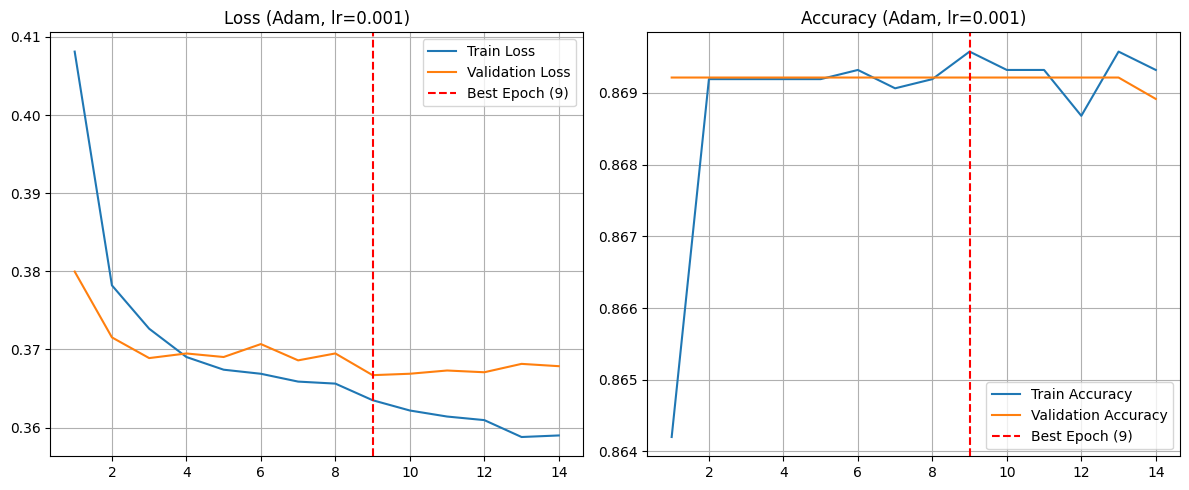

Returning weights from best epoch: 9 (Val Loss: 0.3667)

	 L2 weight decay = 0.01 ---
Epoch 1/30 | Train Loss: 0.4121, Train Acc: 0.8652 | Val Loss: 0.3816, Val Acc: 0.8692	 > Best res (Val Loss: 0.3816)
Epoch 2/30 | Train Loss: 0.3823, Train Acc: 0.8692 | Val Loss: 0.3779, Val Acc: 0.8692	 > Best res (Val Loss: 0.3779)
Epoch 3/30 | Train Loss: 0.3775, Train Acc: 0.8692 | Val Loss: 0.3742, Val Acc: 0.8692	 > Best res (Val Loss: 0.3742)
Epoch 4/30 | Train Loss: 0.3770, Train Acc: 0.8692 | Val Loss: 0.3728, Val Acc: 0.8692	 > Best res (Val Loss: 0.3728)
Epoch 5/30 | Train Loss: 0.3748, Train Acc: 0.8692 | Val Loss: 0.3718, Val Acc: 0.8692	 > Best res (Val Loss: 0.3718)
Epoch 6/30 | Train Loss: 0.3753, Train Acc: 0.8692 | Val Loss: 0.3718, Val Acc: 0.8692	 > Best res (Val Loss: 0.3718)
Epoch 7/30 | Train Loss: 0.3735, Train Acc: 0.8692 | Val Loss: 0.3719, Val Acc: 0.8692	 > No posititve results 1 epochs
Epoch 8/30 | Train Loss: 0.3729, Train Acc: 0.8692 | Val Loss: 0.3723, Val Acc: 0.8692

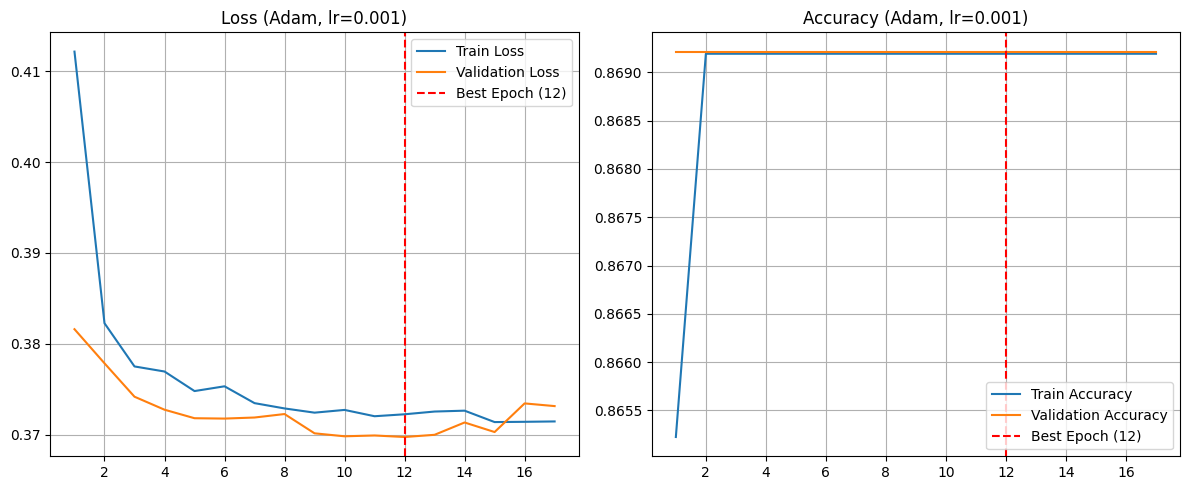

Returning weights from best epoch: 12 (Val Loss: 0.3698)
Weight Decay: 0.0
	 -> Najlepsza Val Acc: 0.8692 | Zatrzymano w epoce: 14
Weight Decay: 0.01
	 -> Najlepsza Val Acc: 0.8692 | Zatrzymano w epoce: 17


In [28]:
optimizer_name = 'Adam'
learning_rate = 0.001
batch_size = 32
num_epochs = 30
patience = 5

l2_rates = [0.0, 0.01]
l2_results = {}

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

for wd in l2_rates:
    print(f"\n\t L2 weight decay = {wd} ---")

    model = DeepFFNN(input_size, hidden1_size, hidden2_size, output_size).to(device)

    results = optimizer_train_and_evaluate(
        model,
        train_loader,
        test_loader,
        optimizer_name=optimizer_name,
        learning_rate=learning_rate,
        weight_decay=wd, #L2 charac
        num_epochs=num_epochs,
        patience=patience,
        device=device,
        verbose=True,
        plot=True
    )

    l2_results[wd] = {
        'best_val_loss': results['best_val_loss'],
        'best_val_acc': results['best_val_acc'],
        'stopped_epoch': results['stopped_epoch']
    }

for wd, metrics in l2_results.items():
    print(f"Weight Decay: {wd}")
    print(f"\t -> Najlepsza Val Acc: {metrics['best_val_acc']:.4f} | "
          f"Zatrzymano w epoce: {metrics['stopped_epoch']}")

**ODPOWIEDŹ**
- W naszym przypadku nie, ponieważ skaźniki overfittingu w obu przypadakach były mniej więcej równe (w obu przypadku overfittingu nie było)

### 11. Redukcja wymiarów danych

* Zastosuj PCA do redukcji liczby cech do różnej liczby komponentów
* Naucz model na danych po PCA.
* Porównaj  dokładność, recall, F1-score i czas treningu.
* **Odpowiedz**: która liczba komponentów daje najlepszy kompromis między redukcją wymiarów a jakością predykcji?

In [30]:
def f1_train_and_evaluate(model,
                          train_loader,
                          test_loader,
                          optimizer_name='Adam',
                          learning_rate=0.001,
                          weight_decay=0.0,
                          num_epochs=50,
                          patience=5,
                          restore_best_weights=True,
                          device='cpu',
                          verbose=False,
                          plot=True):

    model = model.to(device)
    criterion = nn.CrossEntropyLoss()

    if optimizer_name == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    elif optimizer_name == 'RMSProp':
        optimizer = optim.RMSprop(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    elif optimizer_name == 'SGD':
        optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9, weight_decay=weight_decay)
    else:
        raise ValueError(f"ERROR")

    train_losses, train_accs = [], []
    val_losses, val_accs = [], []
    val_f1s, val_recalls = [], []

    best_val_loss = float('inf')
    epochs_no_improve, best_epoch = 0, 0
    best_model_weights = copy.deepcopy(model.state_dict())

    for epoch in range(num_epochs):
        model.train()
        total_loss, correct_train, total_train = 0, 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            outputs = model(xb)
            loss = criterion(outputs, yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * xb.size(0)
            preds = torch.argmax(outputs, dim=1)
            correct_train += (preds == yb).sum().item()
            total_train += yb.size(0)
        train_loss = total_loss / total_train
        train_acc = correct_train / total_train

        model.eval()
        val_loss_total, total_val = 0, 0
        all_val_preds, all_val_labels = [], []

        with torch.no_grad():
            for xb, yb in test_loader:
                xb, yb = xb.to(device), yb.to(device)
                outputs = model(xb)
                loss = criterion(outputs, yb)
                val_loss_total += loss.item() * xb.size(0)
                preds = torch.argmax(outputs, dim=1)

                all_val_preds.append(preds.cpu())
                all_val_labels.append(yb.cpu())
                total_val += yb.size(0)

        val_loss = val_loss_total / total_val
        all_val_preds = torch.cat(all_val_preds).numpy()
        all_val_labels = torch.cat(all_val_labels).numpy()

        val_acc = accuracy_score(all_val_labels, all_val_preds)
        val_f1 = f1_score(all_val_labels, all_val_preds, average='macro')
        val_recall = recall_score(all_val_labels, all_val_preds, average='macro')

        train_losses.append(train_loss); train_accs.append(train_acc)
        val_losses.append(val_loss); val_accs.append(val_acc)
        val_f1s.append(val_f1); val_recalls.append(val_recall)

        if verbose:
            print(f"Epoch {epoch+1}/{num_epochs} | "
                  f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
                  f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, Val F1: {val_f1:.4f}", end="")

        # EARLY STOPPING CHECK
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            best_model_weights = copy.deepcopy(model.state_dict())
            best_epoch = epoch + 1
            if verbose:
                print(f"\t > Best res (Val Loss: {best_val_loss:.4f})")
        else:
            epochs_no_improve += 1
            if verbose:
                print(f"\t > No posititve results {epochs_no_improve} epochs")

        if epochs_no_improve >= patience:
            print(f"\nEARLY STOPPING! After {epoch + 1} epochs.")
            break

    if plot:
        epochs_range = range(1, len(train_losses) + 1)
        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1)
        plt.plot(epochs_range, train_losses, label='Train Loss')
        plt.plot(epochs_range, val_losses, label='Validation Loss')
        plt.axvline(best_epoch, color='r', linestyle='--', label=f'Best Epoch ({best_epoch})')
        plt.title(f'Loss ({optimizer_name}, lr={learning_rate})')
        plt.legend()
        plt.grid(True)
        plt.subplot(1, 2, 2)
        plt.plot(epochs_range, train_accs, label='Train Accuracy')
        plt.plot(epochs_range, val_accs, label='Validation Accuracy')
        plt.axvline(best_epoch, color='r', linestyle='--', label=f'Best Epoch ({best_epoch})')
        plt.title(f'Accuracy ({optimizer_name}, lr={learning_rate})')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    if restore_best_weights:
        print(f"Returning weights from best epoch: {best_epoch} (Val Loss: {best_val_loss:.4f})")
        model.load_state_dict(best_model_weights)

    return {
        'model': model,
        'best_val_loss': best_val_loss,
        'best_val_acc': val_accs[best_epoch-1],
        'best_val_f1': val_f1s[best_epoch-1],
        'best_val_recall': val_recalls[best_epoch-1],
        'stopped_epoch': len(train_losses)
    }

In [36]:
from sklearn.decomposition import PCA

pca_results = {}

components_to_test = [14, 12, 10, 8, 3]
best_optimizer = 'Adam'
best_lr = 0.001
batch_size = 32

for n_comp in components_to_test:
    label = f"n={n_comp}"
    print(f"\n\t Components: {label}")

    pca = PCA(n_components=n_comp)
    X_train_processed = pca.fit_transform(X_train)
    X_test_processed = pca.transform(X_test)

    X_train_pca_tensor = torch.FloatTensor(X_train_processed)
    X_test_pca_tensor = torch.FloatTensor(X_test_processed)

    train_dataset_pca = TensorDataset(X_train_pca_tensor, y_train_tensor)
    test_dataset_pca = TensorDataset(X_test_pca_tensor, y_test_tensor)

    train_loader_pca = DataLoader(train_dataset_pca, batch_size=batch_size, shuffle=True)
    test_loader_pca = DataLoader(test_dataset_pca, batch_size=batch_size, shuffle=False)

    model_pca = DeepFFNN(
        input_size=n_comp,
        hidden1_size=hidden1_size,
        hidden2_size=hidden2_size,
        output_size=output_size
    ).to(device)

    start_time = time.time()

    results = f1_train_and_evaluate(
        model_pca,
        train_loader_pca,
        test_loader_pca,
        optimizer_name=best_optimizer,
        learning_rate=best_lr,
        num_epochs=50,
        patience=5,
        device=device,
        verbose=False,
        plot=False
    )

    duration = time.time() - start_time

    pca_results[label] = {
        'time_sec': duration,
        'accuracy': results['best_val_acc'],
        'f1_score': results['best_val_f1'],
        'recall': results['best_val_recall'],
        'stopped_epoch': results['stopped_epoch']
    }

    print(f"\t Time: {duration:.2f} sec. Best F1: {results['best_val_f1']:.4f}")

print(f"\n\n{'Components':<15} | {'Times':<10} | {'Accuracy':<10} | {'F1-Score':<10} | {'Recall':<10} | {'Epochs':<5}")
print("-" * 80)
for n_str, metrics in pca_results.items():
    print(f"{n_str:<15} | {metrics['time_sec']:<10.2f} | "
          f"{metrics['accuracy']:<10.4f} | "
          f"{metrics['f1_score']:<10.4f} | "
          f"{metrics['recall']:<10.4f} | {metrics['stopped_epoch']:<5}")


	 Components: n=14

EARLY STOPPING! After 13 epochs.
Returning weights from best epoch: 8 (Val Loss: 0.3639)
	 Time: 4.44 sec. Best F1: 0.4650

	 Components: n=12

EARLY STOPPING! After 15 epochs.
Returning weights from best epoch: 10 (Val Loss: 0.3702)
	 Time: 4.72 sec. Best F1: 0.4650

	 Components: n=10

EARLY STOPPING! After 12 epochs.
Returning weights from best epoch: 7 (Val Loss: 0.3742)
	 Time: 3.44 sec. Best F1: 0.4650

	 Components: n=8

EARLY STOPPING! After 20 epochs.
Returning weights from best epoch: 15 (Val Loss: 0.3708)
	 Time: 6.11 sec. Best F1: 0.4648

	 Components: n=3

EARLY STOPPING! After 38 epochs.
Returning weights from best epoch: 33 (Val Loss: 0.3706)
	 Time: 11.23 sec. Best F1: 0.4648


Components      | Times      | Accuracy   | F1-Score   | Recall     | Epochs
--------------------------------------------------------------------------------
n=14            | 4.44       | 0.8692     | 0.4650     | 0.5000     | 13   
n=12            | 4.72       | 0.8692     

**ODPOWIEDŹ**

- W naszym przypadku najlepszy wynik mamy przy 10 komponentach (zajęło najmniej czasu i jej najwyższy Accuracy i F1-score, Recall)